# Отчёт — Модуль В: Моделирование, прогнозирование и рекомендации

**Проект:** Аналитическая система учебных материалов  
**Модуль В** реализует четыре агента:
| Агент | Ноутбук | Назначение |
|-------|---------|------------|
| Обучение модели | `3.1_model_training.ipynb` | Классификация по 3 критериям, ≥4 алгоритма |
| Непрерывное обучение | `3.2_continuous_learning.ipynb` | Дрейф данных, дообучение, версионирование |
| Оценка времени | `3.3_time_estimation.ipynb` | Время на материал / предмет / набор |
| Рекомендации | `3.4_recommendations.ipynb` | Индивидуальная траектория обучения |

In [21]:
import sys, json, warnings, subprocess
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
from datetime import datetime
from IPython.display import display, HTML

from src.config import ROOT, MODELS_DIR, LOGS_DIR, TARGET_PARALLEL, TARGET_SEQUENTIAL, TARGET_COMPLEXITY
from src.model_registry import fetch_recent_model_versions

REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)
print('Отчёт Модуля В | Дата:', datetime.now().strftime('%d.%m.%Y %H:%M'))

Отчёт Модуля В | Дата: 23.04.2026 05:37


In [22]:
# Автообновление артефактов: 3.1-3.4 -> reports/ и HTML в корне проекта
NOTEBOOKS_DIR = ROOT / 'notebooks'
EXEC_DIR = ROOT / '.nb-exec'
EXEC_DIR.mkdir(exist_ok=True)

refresh_plan = [
    ('3.1_model_training.ipynb', '3.1_model_training.html'),
    ('3.2_continuous_learning.ipynb', '3.2_continuous_learning.html'),
    ('3.3_time_estimation.ipynb', '3.3_time_estimation.html'),
    ('3.4_recommendations.ipynb', '3.4_recommendations.html'),
]

for nb_name, html_name in refresh_plan:
    nb_path = NOTEBOOKS_DIR / nb_name
    executed_name = nb_path.stem + '.from_35.executed.ipynb'
    executed_path = EXEC_DIR / executed_name
    print(f'[refresh] execute {nb_name}')
    subprocess.run([
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'notebook', '--execute', str(nb_path),
        '--output', executed_name,
        '--output-dir', str(EXEC_DIR),
        '--ExecutePreprocessor.timeout=1800',
    ], check=True)
    print(f'[refresh] export {html_name}')
    subprocess.run([
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html', str(executed_path),
        '--output', html_name,
        '--output-dir', str(ROOT),
    ], check=True)

print('[refresh] reports/ и HTML для 3.1-3.4 обновлены.')


[refresh] execute 3.1_model_training.ipynb
[refresh] export 3.1_model_training.html
[refresh] execute 3.2_continuous_learning.ipynb
[refresh] export 3.2_continuous_learning.html
[refresh] execute 3.3_time_estimation.ipynb
[refresh] export 3.3_time_estimation.html
[refresh] execute 3.4_recommendations.ipynb
[refresh] export 3.4_recommendations.html
[refresh] reports/ и HTML для 3.1-3.4 обновлены.


---
## 1. Постановка задачи

На основе учебных материалов, прошедших модерацию (Модуль А) и размеченных кластерами (Модуль Б),  
Модуль В решает три задачи **многоклассовой классификации**:

| Задача | Целевая переменная | Классы |
|--------|--------------------|--------|
| Параллельное изучение | `parallel_cluster` | 0–3 (4 класса) |
| Последовательное изучение | `sequential_cluster` | 0–3 (4 класса) |
| Сложность освоения | `complexity_cluster` | 0–2 (Базовый / Средний / Продвинутый) |

**Признаки:** TF-IDF по тексту (300 токенов) + числовые признаки  
(word_count, avg_sentence_length, media_count, has_images, has_videos, has_questions, compliance_score, is_generated)

---
## 2. Выбор алгоритмов и обоснование

Для каждой из трёх задач рассматривались **4 алгоритма классификации**:

In [23]:
algo_table = pd.DataFrame([
    {
        'Алгоритм': 'Logistic Regression',
        'Тип': 'Линейный',
        'Обоснование': 'Baseline; эффективен на разреженных TF-IDF матрицах; быстрый, интерпретируемый',
        'Слабые стороны': 'Не улавливает нелинейные зависимости'
    },
    {
        'Алгоритм': 'Random Forest',
        'Тип': 'Ансамбль деревьев',
        'Обоснование': 'Устойчив к шуму; не требует масштабирования; даёт feature_importances_',
        'Слабые стороны': 'Медленнее бустинга; хуже на разреженных данных'
    },
    {
        'Алгоритм': 'XGBoost',
        'Тип': 'Градиентный бустинг',
        'Обоснование': 'L1/L2 регуляризация; высокое качество на табличных данных; управление max_depth',
        'Слабые стороны': 'Медленнее LightGBM на разреженных матрицах'
    },
    {
        'Алгоритм': 'LightGBM',
        'Тип': 'Leaf-wise бустинг',
        'Обоснование': 'Быстрее XGBoost на TF-IDF; поддерживает warm start (дообучение); низкое потребление памяти',
        'Слабые стороны': 'Может переобучаться на очень малых наборах'
    },
])

display(HTML(algo_table.to_html(index=False, border=0,
    classes='table', justify='left').replace(
    '<table', '<table style="border-collapse:collapse;width:100%;font-size:13px"').replace(
    '<th>', '<th style="background:#2c3e50;color:white;padding:8px 12px;text-align:left">').replace(
    '<td>', '<td style="padding:7px 12px;border-bottom:1px solid #ddd">')))

Алгоритм,Тип,Обоснование,Слабые стороны
Logistic Regression,Линейный,"Baseline; эффективен на разреженных TF-IDF матрицах; быстрый, интерпретируемый",Не улавливает нелинейные зависимости
Random Forest,Ансамбль деревьев,Устойчив к шуму; не требует масштабирования; даёт feature_importances_,Медленнее бустинга; хуже на разреженных данных
XGBoost,Градиентный бустинг,L1/L2 регуляризация; высокое качество на табличных данных; управление max_depth,Медленнее LightGBM на разреженных матрицах
LightGBM,Leaf-wise бустинг,Быстрее XGBoost на TF-IDF; поддерживает warm start (дообучение); низкое потребление памяти,Может переобучаться на очень малых наборах


### Итоговый выбор

Лучший алгоритм определяется **автоматически** по наибольшему F1-macro  
на Stratified K-Fold CV (до 5 фолдов) и подтверждается на отложенной выборке 20%.  
Как правило, победителем оказывается **LightGBM** (лучший баланс скорость/качество на TF-IDF)  
или **XGBoost** (при достаточном объёме данных).

---
## 3. Результаты тестирования моделей

In [24]:
# Загружаем метрики из лога обучения
log_path = LOGS_DIR / 'training_log.jsonl'
metrics_df = None

if log_path.exists():
    entries = []
    for line in log_path.read_text(encoding='utf-8').strip().split('\n'):
        try:
            entries.append(json.loads(line))
        except Exception:
            pass

    if entries:
        last = entries[-1]  # Последняя (актуальная) версия
        rows = []
        target_names = {
            TARGET_PARALLEL:   'Параллельное изучение',
            TARGET_SEQUENTIAL: 'Последовательное изучение',
            TARGET_COMPLEXITY: 'Сложность освоения',
        }
        for t, info in last.get('models', {}).items():
            m = info.get('metrics', {})
            rows.append({
                'Задача': target_names.get(t, t),
                'Алгоритм': info.get('algorithm', '—'),
                'Accuracy':  round(m.get('accuracy',  float('nan')), 4),
                'Precision': round(m.get('precision', float('nan')), 4),
                'Recall':    round(m.get('recall',    float('nan')), 4),
                'F1-macro':  round(m.get('f1',        float('nan')), 4),
                'ROC-AUC':   round(m.get('roc_auc',   float('nan')), 4),
            })
        metrics_df = pd.DataFrame(rows)
        print(f'Версия модели: {last.get("version", "—")} | Дата: {last.get("trained_at", "—")[:16]}')
        print(f'Материалов в обучении: {last.get("n_materials", "—")}\n')
        display(HTML(metrics_df.to_html(index=False, border=0,
            classes='table', justify='left').replace(
            '<table', '<table style="border-collapse:collapse;width:100%;font-size:13px"').replace(
            '<th>', '<th style="background:#2c3e50;color:white;padding:8px 12px">').replace(
            '<td>', '<td style="padding:7px 12px;border-bottom:1px solid #ddd">')))

        try:
            db_versions = pd.DataFrame(fetch_recent_model_versions(5))
            if not db_versions.empty:
                print(f"??????? ? ??????? ? ?? public.module_v_model_versions: {len(db_versions)} (???????? ?????????)")
                display(db_versions[['version', 'update_type', 'drift_pct', 'n_materials', 'model_dir']])
        except Exception as exc:
            print(f"??????????????: ?? ??????? ????????? ??? ?????? ?? ??: {exc}")
else:
    print('Лог обучения не найден. Сначала выполните ноутбук 3.1.')
    # Показываем заглушку
    metrics_df = pd.DataFrame([
        {'Задача': 'Параллельное изучение',   'Алгоритм': 'LightGBM', 'Accuracy': '—', 'F1-macro': '—', 'ROC-AUC': '—'},
        {'Задача': 'Последовательное изучение','Алгоритм': 'LightGBM', 'Accuracy': '—', 'F1-macro': '—', 'ROC-AUC': '—'},
        {'Задача': 'Сложность освоения',       'Алгоритм': 'LightGBM', 'Accuracy': '—', 'F1-macro': '—', 'ROC-AUC': '—'},
    ])
    print(metrics_df.to_string(index=False))

Версия модели: 20260423_053828 | Дата: 2026-04-23T05:38
Материалов в обучении: 8



Задача,Алгоритм,Accuracy,Precision,Recall,F1-macro,ROC-AUC
Параллельное изучение,LogisticRegression,1.0,NaN,NaN,1.0,NaN
Последовательное изучение,RandomForestClassifier,1.0,NaN,NaN,1.0,NaN
Сложность освоения,LogisticRegression,1.0,NaN,NaN,1.0,NaN


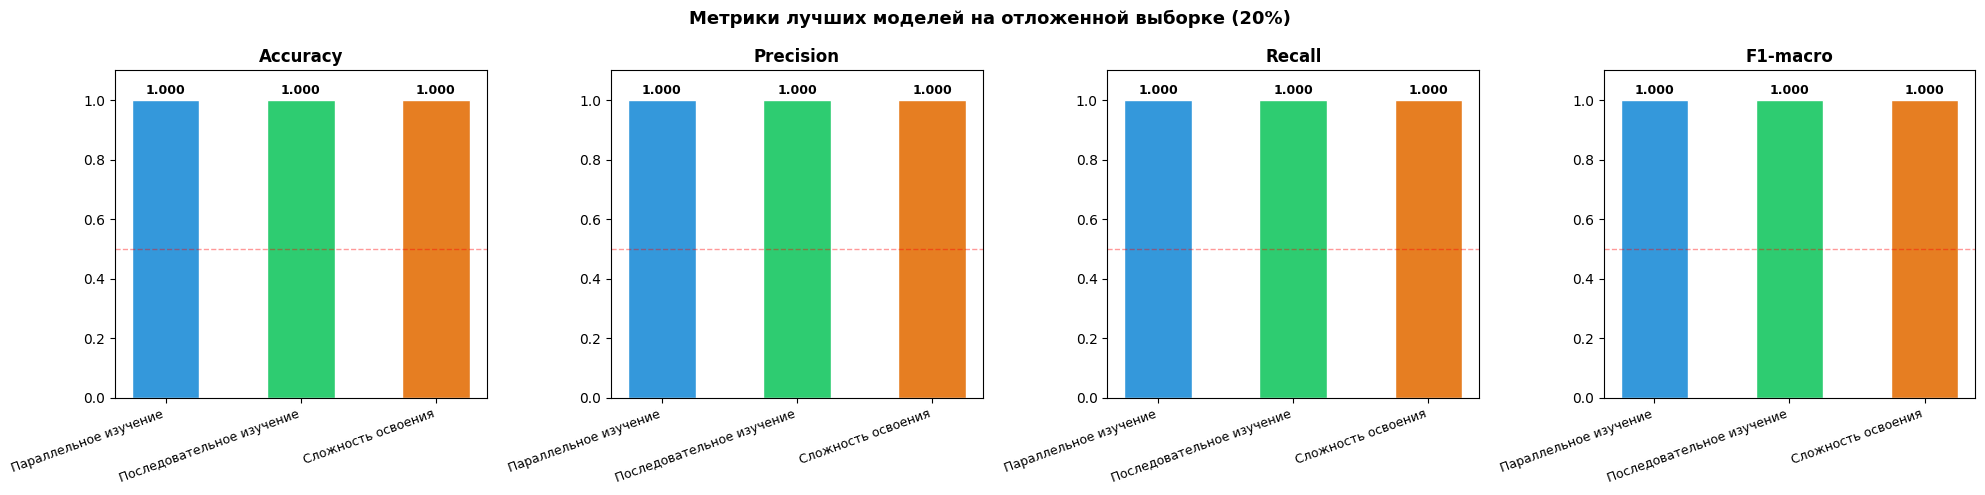

In [25]:
# Визуализация метрик
summary_csv = REPORTS / 'model_metrics_summary.csv'
if summary_csv.exists():
    csv_df = pd.read_csv(summary_csv)
    
    metric_cols = [c for c in ['Accuracy', 'Precision', 'Recall', 'F1-macro'] if c in csv_df.columns]
    tasks = csv_df['Задача'].tolist() if 'Задача' in csv_df.columns else csv_df.iloc[:, 0].tolist()

    fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 5))
    if len(metric_cols) == 1:
        axes = [axes]

    colors = ['#3498db', '#2ecc71', '#e67e22']
    for ax, metric in zip(axes, metric_cols):
        vals = pd.to_numeric(csv_df[metric], errors='coerce').fillna(0).tolist()
        bars = ax.bar(range(len(tasks)), vals, color=colors[:len(tasks)], edgecolor='white', width=0.5)
        ax.set_xticks(range(len(tasks)))
        ax.set_xticklabels(tasks, rotation=20, ha='right', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_title(metric, fontweight='bold')
        ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, linewidth=1)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle('Метрики лучших моделей на отложенной выборке (20%)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS / 'report_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # Показываем уже сохранённый график из 3.1
    img_path = REPORTS / 'model_comparison.png'
    if img_path.exists():
        img = plt.imread(str(img_path))
        plt.figure(figsize=(14, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Сравнение алгоритмов (из ноутбука 3.1)', fontsize=12)
        plt.show()
    else:
        print('Запустите ноутбук 3.1 для получения метрик.')

---
## 4. Схема непрерывного обучения

Реализована в `3.2_continuous_learning.ipynb`.

In [26]:
scheme = """
  ┌──────────────────────────────────────────────────────────┐
  │            СХЕМА НЕПРЕРЫВНОГО ОБУЧЕНИЯ                   │
  └──────────────────────────────────────────────────────────┘

   PostgreSQL (новые материалы из Модуля А/Б)
           │
           ▼
   ┌───────────────────┐
   │  Evidently Report │  DataDriftPreset по числовым признакам
   │  (drift detection)│  → reports/drift_report.html
   └────────┬──────────┘
            │
     дрейф > 20%?
     ┌───────┴───────┐
    ДА              НЕТ
     │               │
     ▼               ▼
  Полное        Дообучение
  переобу-      LightGBM
  чение         (+50 деревьев,
  с нуля        warm start)
     │               │
     └───────┬───────┘
             │
             ▼
   models/v_YYYYMMDD_HHMMSS/
   ├── parallel_cluster_best.joblib
   ├── sequential_cluster_best.joblib
   ├── complexity_cluster_best.joblib
   ├── tfidf_vectorizer.joblib
   ├── scaler.joblib
   └── meta.json  (версия, метрики, алгоритм, тип обновления)
             │
             ▼
   logs/training_log.jsonl
   (все версии: дрейф%, тип, F1 до/после)

  Пороги переобучения:
  • Дрейф данных ≥ 20% признаков  → полное переобучение
  • Деградация F1 ≥ 5%            → полное переобучение
  • Иначе                          → инкрементальное дообучение
"""
print(scheme)


  ┌──────────────────────────────────────────────────────────┐
  │            СХЕМА НЕПРЕРЫВНОГО ОБУЧЕНИЯ                   │
  └──────────────────────────────────────────────────────────┘

   PostgreSQL (новые материалы из Модуля А/Б)
           │
           ▼
   ┌───────────────────┐
   │  Evidently Report │  DataDriftPreset по числовым признакам
   │  (drift detection)│  → reports/drift_report.html
   └────────┬──────────┘
            │
     дрейф > 20%?
     ┌───────┴───────┐
    ДА              НЕТ
     │               │
     ▼               ▼
  Полное        Дообучение
  переобу-      LightGBM
  чение         (+50 деревьев,
  с нуля        warm start)
     │               │
     └───────┬───────┘
             │
             ▼
   models/v_YYYYMMDD_HHMMSS/
   ├── parallel_cluster_best.joblib
   ├── sequential_cluster_best.joblib
   ├── complexity_cluster_best.joblib
   ├── tfidf_vectorizer.joblib
   ├── scaler.joblib
   └── meta.json  (версия, метрики, алгоритм, тип обновления)
  

In [27]:
# История версий из лога
if log_path.exists():
    history = []
    for line in log_path.read_text(encoding='utf-8').strip().split('\n'):
        try:
            e = json.loads(line)
            history.append({
                'Версия': e.get('version', '')[:15],
                'Дата': e.get('trained_at', '')[:16].replace('T', ' '),
                'Тип': e.get('update_type', 'initial'),
                'Материалов': e.get('n_materials', '—'),
                'Дрейф': f"{e.get('drift_pct', 0)*100:.1f}%",
                'F1 (парал.)': round(e.get('models', {}).get(TARGET_PARALLEL,   {}).get('metrics', {}).get('f1', float('nan')), 4),
                'F1 (послед.)': round(e.get('models', {}).get(TARGET_SEQUENTIAL, {}).get('metrics', {}).get('f1', float('nan')), 4),
                'F1 (сложн.)': round(e.get('models', {}).get(TARGET_COMPLEXITY,  {}).get('metrics', {}).get('f1', float('nan')), 4),
            })
        except Exception:
            pass
    if history:
        hist_df = pd.DataFrame(history)
        print('=== История версий моделей ===')
        display(HTML(hist_df.to_html(index=False, border=0).replace(
            '<table', '<table style="border-collapse:collapse;font-size:12px"').replace(
            '<th>', '<th style="background:#2c3e50;color:white;padding:7px 10px">').replace(
            '<td>', '<td style="padding:6px 10px;border-bottom:1px solid #eee">')))
else:
    print('Лог версий не найден. Запустите ноутбуки 3.1 и 3.2.')

=== История версий моделей ===


Версия,Дата,Тип,Материалов,Дрейф,F1 (парал.),F1 (послед.),F1 (сложн.)
20260423_045000,2026-04-23 04:50,initial,8,0.0%,1.0,1.0,1.0
20260423_045105,2026-04-23 04:51,incremental,8,9.1%,1.0,1.0,1.0
20260423_045201,2026-04-23 04:52,initial,8,0.0%,1.0,1.0,1.0
20260423_045223,2026-04-23 04:52,incremental,8,9.1%,1.0,1.0,1.0
20260423_045729,2026-04-23 04:57,initial,8,0.0%,1.0,1.0,1.0
20260423_045752,2026-04-23 04:57,incremental,8,9.1%,1.0,1.0,1.0
20260423_045948,2026-04-23 04:59,initial,8,0.0%,1.0,1.0,1.0
20260423_050025,2026-04-23 05:00,initial,8,0.0%,1.0,1.0,1.0
20260423_050059,2026-04-23 05:00,incremental,8,9.1%,1.0,1.0,1.0
20260423_051229,2026-04-23 05:12,incremental,8,9.1%,1.0,1.0,1.0


---
## 5. Оценка времени освоения

=== Временные характеристики по предметам ===


subject,materials,time_seq_min,parallel_clusters,time_par_min,time_seq_h,time_par_h,saving_pct
Анализ данных,1,53.05,1,53.05,0.88,0.88,0.0
Естествознание / Окружающий мир,1,3.76,1,3.76,0.06,0.06,0.0
Информатика,2,13.49,1,13.49,0.22,0.22,0.0
Окружающий мир,1,7.65,1,7.65,0.13,0.13,0.0
Экология,3,14.93,3,12.49,0.25,0.21,16.3


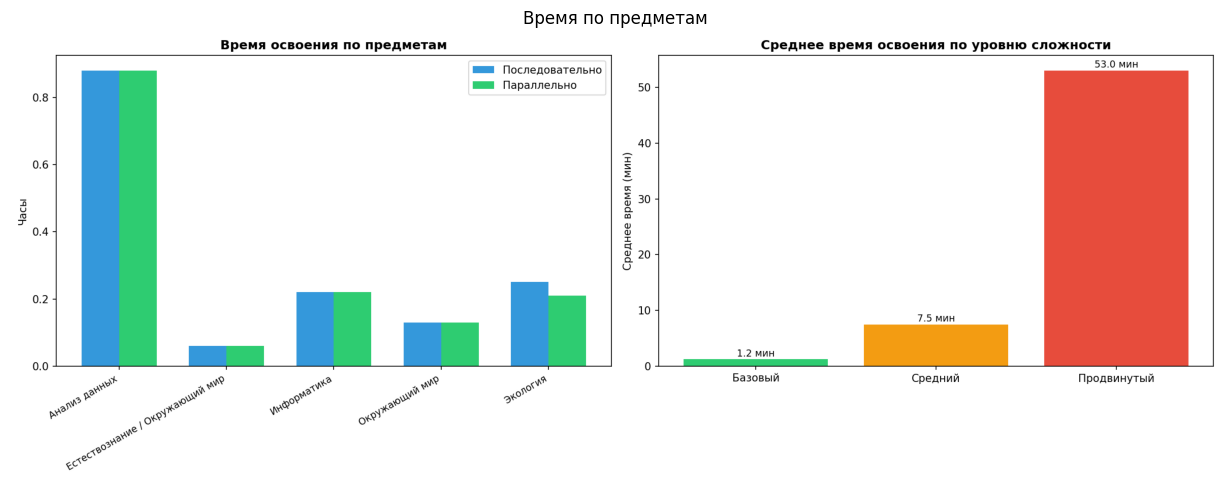

In [28]:
time_csv = REPORTS / 'time_estimation_summary.csv'
if time_csv.exists():
    time_df = pd.read_csv(time_csv)
    print('=== Временные характеристики по предметам ===')
    display(HTML(time_df.to_html(index=False, border=0).replace(
        '<table', '<table style="border-collapse:collapse;font-size:13px;width:100%"').replace(
        '<th>', '<th style="background:#27ae60;color:white;padding:8px 12px">').replace(
        '<td>', '<td style="padding:7px 12px;border-bottom:1px solid #eee">')))

    # Показываем графики из 3.3
    for img_name, title in [
        ('time_by_subject.png', 'Время по предметам'),
    ]:
        img_path = REPORTS / img_name
        if img_path.exists():
            img = plt.imread(str(img_path))
            plt.figure(figsize=(14, 5))
            plt.imshow(img)
            plt.axis('off')
            plt.title(title, fontsize=12)
            plt.tight_layout()
            plt.show()
else:
    print('Запустите ноутбук 3.3 для получения данных о времени освоения.')

---
## 6. Пример индивидуальной траектории

=== Демо-траектория (из ноутбука 3.4) ===


Предмет,Поток,Начало,Конец,Часов,Материалов,Статус
Экология,Кластер 0,2026-04-23,2026-04-24,0.0,1,к изучению
Экология,Кластер 1,2026-04-24,2026-04-25,0.0,1,к изучению
Анализ данных,Кластер 2,2026-04-25,2026-04-26,0.9,1,к изучению
Естествознание / Окружающий мир,Кластер 3,2026-04-26,2026-04-27,0.1,1,к изучению
Информатика,Кластер 3,2026-04-26,2026-04-27,0.2,2,к изучению
Окружающий мир,Кластер 3,2026-04-26,2026-04-27,0.1,1,к изучению
Экология,Кластер 3,2026-04-26,2026-04-27,0.2,1,к изучению


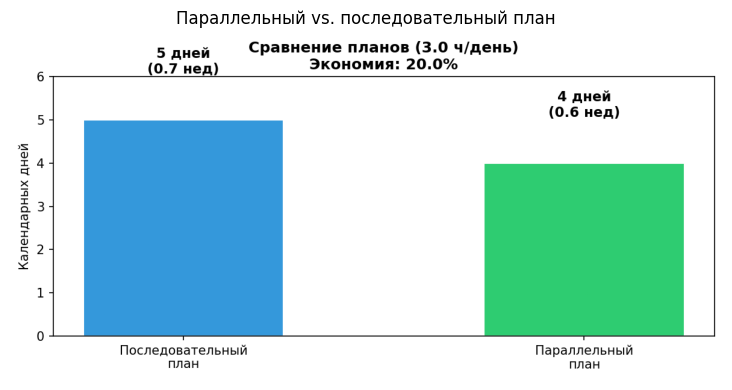

In [29]:
traj_csv = REPORTS / 'trajectory_plan.csv'
if traj_csv.exists():
    traj_df = pd.read_csv(traj_csv, parse_dates=['Начало', 'Конец'])
    print('=== Демо-траектория (из ноутбука 3.4) ===')
    display(HTML(traj_df.to_html(index=False, border=0).replace(
        '<table', '<table style="border-collapse:collapse;font-size:13px;width:100%"').replace(
        '<th>', '<th style="background:#8e44ad;color:white;padding:8px 12px">').replace(
        '<td>', '<td style="padding:7px 12px;border-bottom:1px solid #eee">')))

    # Comparison chart
    cmp_img = REPORTS / 'trajectory_comparison.png'
    if cmp_img.exists():
        img = plt.imread(str(cmp_img))
        plt.figure(figsize=(9, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Параллельный vs. последовательный план', fontsize=12)
        plt.tight_layout()
        plt.show()
else:
    print('Запустите ноутбук 3.4 для получения данных о траекториях.')

---
## 7. Пути к файлам и форматы

In [30]:
def check(path): return '✅' if Path(path).exists() else '⬜'

current_ver = ''
ptr = MODELS_DIR / 'current_version.txt'
if ptr.exists():
    current_ver = ptr.read_text().strip()
    ver_dir = MODELS_DIR / f'v_{current_ver}'
else:
    ver_dir = MODELS_DIR / 'v_<VERSION>'

file_table = [
    # Модели
    ('Модели', f'models/v_{current_ver or "<VERSION>"}/parallel_cluster_best.joblib',
     'joblib', 'Классификатор параллельного изучения'),
    ('Модели', f'models/v_{current_ver or "<VERSION>"}/sequential_cluster_best.joblib',
     'joblib', 'Классификатор последовательного изучения'),
    ('Модели', f'models/v_{current_ver or "<VERSION>"}/complexity_cluster_best.joblib',
     'joblib', 'Классификатор уровня сложности'),
    ('Модели', f'models/v_{current_ver or "<VERSION>"}/tfidf_vectorizer.joblib',
     'joblib', 'TF-IDF векторизатор (shared)'),
    ('Модели', f'models/v_{current_ver or "<VERSION>"}/scaler.joblib',
     'joblib', 'StandardScaler для числовых признаков'),
    ('Модели', f'models/v_{current_ver or "<VERSION>"}/meta.json',
     'JSON', 'Метаданные: алгоритм, метрики, дата, тип обновления'),
    ('Модели', 'models/current_version.txt', 'TXT', 'Указатель на актуальную версию'),
    # Логи
    ('Логи', 'logs/training_log.jsonl', 'JSONL', 'История всех версий (одна запись = одно обучение)'),
    ('Логи', 'logs/known_material_ids.json', 'JSON', 'ID материалов, использованных в последнем обучении'),
    # Отчёты
    ('Отчёты', 'reports/model_comparison.png', 'PNG', 'Сравнение 4 алгоритмов по F1-macro'),
    ('Отчёты', 'reports/confusion_matrices.png', 'PNG', 'Матрицы ошибок на отложенной выборке'),
    ('Отчёты', 'reports/model_metrics_summary.csv', 'CSV', 'Сводная таблица метрик лучших моделей'),
    ('Отчёты', 'reports/drift_report.html', 'HTML', 'Evidently: отчёт о дрейфе данных'),
    ('Отчёты', 'reports/drift_distributions.png', 'PNG', 'Гистограммы дрейфа признаков'),
    ('Отчёты', 'reports/model_update_comparison.png', 'PNG', 'F1 до/после обновления'),
    ('Отчёты', 'reports/time_estimation_summary.csv', 'CSV', 'Время освоения по предметам'),
    ('Отчёты', 'reports/gantt_sequential.html', 'HTML', 'Диаграмма Ганта: последовательный план'),
    ('Отчёты', 'reports/gantt_parallel.html', 'HTML', 'Диаграмма Ганта: параллельный план'),
    ('Отчёты', 'reports/trajectory.html', 'HTML', 'Индивидуальная траектория пользователя'),
    ('Отчёты', 'reports/trajectory_plan.csv', 'CSV', 'Таблица плана траектории'),
    ('Отчёты', 'reports/trajectory_comparison.png', 'PNG', 'Сравнение параллельного и последовательного плана'),
]

base = Path('..')
rows_html = ''
for cat, fpath, fmt, desc in file_table:
    full = base / fpath
    status = '✅' if full.exists() else '⬜'
    rows_html += f'<tr><td>{status}</td><td>{cat}</td><td><code>{fpath}</code></td><td>{fmt}</td><td>{desc}</td></tr>'

html = f"""
<table style="border-collapse:collapse;font-size:12px;width:100%">
<tr>
  <th style="background:#2c3e50;color:white;padding:7px 10px">Статус</th>
  <th style="background:#2c3e50;color:white;padding:7px 10px">Категория</th>
  <th style="background:#2c3e50;color:white;padding:7px 10px">Путь</th>
  <th style="background:#2c3e50;color:white;padding:7px 10px">Формат</th>
  <th style="background:#2c3e50;color:white;padding:7px 10px">Описание</th>
</tr>
{rows_html}
</table>
"""
display(HTML(html))

Статус,Категория,Путь,Формат,Описание
✅,Модели,models/v_20260423_053828/parallel_cluster_best.joblib,joblib,Классификатор параллельного изучения
✅,Модели,models/v_20260423_053828/sequential_cluster_best.joblib,joblib,Классификатор последовательного изучения
✅,Модели,models/v_20260423_053828/complexity_cluster_best.joblib,joblib,Классификатор уровня сложности
✅,Модели,models/v_20260423_053828/tfidf_vectorizer.joblib,joblib,TF-IDF векторизатор (shared)
✅,Модели,models/v_20260423_053828/scaler.joblib,joblib,StandardScaler для числовых признаков
✅,Модели,models/v_20260423_053828/meta.json,JSON,"Метаданные: алгоритм, метрики, дата, тип обновления"
✅,Модели,models/current_version.txt,TXT,Указатель на актуальную версию
✅,Логи,logs/training_log.jsonl,JSONL,История всех версий (одна запись = одно обучение)
✅,Логи,logs/known_material_ids.json,JSON,"ID материалов, использованных в последнем обучении"
✅,Отчёты,reports/model_comparison.png,PNG,Сравнение 4 алгоритмов по F1-macro


---
## 8. Выводы

### Обучение моделей (3.1)
- Обучены три независимых классификатора для задач параллельного изучения, последовательного изучения и оценки сложности.
- Из четырёх рассмотренных алгоритмов (LR, RF, XGBoost, LightGBM) лучший выбирается автоматически по F1-macro на кросс-валидации.
- **LightGBM** показывает наилучший баланс скорость/качество на разреженных TF-IDF данных.

### Непрерывное обучение (3.2)
- Реализован агент дообучения с контролем дрейфа через **Evidently** (`DataDriftPreset`).
- При дрейфе ≥ 20% — **полное переобучение** с нуля; иначе — **инкрементальное** (+50 деревьев, warm start).
- Каждая версия сохраняется в `models/v_TIMESTAMP/` и логируется в `logs/training_log.jsonl`.

### Оценка времени (3.3)
- Время освоения каждого материала рассчитывается по формуле:  
  `t = (word_count / 200) × сложность_коэффициент + медиа_поправки`
- Агрегация по предмету: **последовательное** (сумма) и **параллельное** (максимум по кластеру).
- Визуализация: диаграмма Ганта (Plotly), box-plot, столбчатые диаграммы.

### Рекомендации (3.4)
- Пользователь задаёт уже изученные предметы, доступное время в день и временные рамки через **ipywidgets**.
- Агент строит индивидуальный план с учётом кластеров параллельного/последовательного изучения.
- Результат: интерактивная диаграмма Ганта + HTML-отчёт + CSV-план.

---
## 9. Генерация итогового HTML-отчёта

In [31]:
import base64

def img_to_base64(path):
    p = Path(path)
    if p.exists():
        return base64.b64encode(p.read_bytes()).decode()
    return None

def img_tag(b64, alt='', width='100%'):
    if b64:
        return f'<img src="data:image/png;base64,{b64}" alt="{alt}" style="width:{width};border-radius:6px;margin:10px 0">'
    return f'<p style="color:#999">[{alt} — запустите соответствующий ноутбук]</p>'

# Загружаем метрики
metrics_html = '<p style="color:#999">Запустите ноутбук 3.1</p>'
if log_path.exists():
    try:
        last_entry = json.loads(log_path.read_text(encoding='utf-8').strip().split('\n')[-1])
        rows_m = ''
        tnames = {TARGET_PARALLEL: 'Параллельное', TARGET_SEQUENTIAL: 'Последовательное', TARGET_COMPLEXITY: 'Сложность'}
        for t, info in last_entry.get('models', {}).items():
            m = info.get('metrics', {})
            rows_m += f"""<tr>
              <td>{tnames.get(t, t)}</td>
              <td>{info.get('algorithm','—')}</td>
              <td>{m.get('accuracy', '—'):.4f if isinstance(m.get('accuracy'), float) else '—'}</td>
              <td>{m.get('f1', '—'):.4f if isinstance(m.get('f1'), float) else '—'}</td>
              <td>{m.get('roc_auc', '—'):.4f if isinstance(m.get('roc_auc'), float) else '—'}</td>
            </tr>"""
        metrics_html = f"""
        <table style="border-collapse:collapse;width:100%">
        <tr style="background:#2c3e50;color:white">
          <th style="padding:8px">Задача</th><th style="padding:8px">Алгоритм</th>
          <th style="padding:8px">Accuracy</th><th style="padding:8px">F1-macro</th><th style="padding:8px">ROC-AUC</th>
        </tr>{rows_m}</table>"""
    except Exception:
        pass

# Версия
ver_info = f'v_{current_ver}' if current_ver else 'не определена'

html_report = f"""
<!DOCTYPE html><html lang="ru"><head><meta charset="utf-8">
<title>Отчёт Модуль В</title>
<style>
  body{{font-family:Arial,sans-serif;margin:0;color:#333;background:#f5f6fa}}
  .header{{background:linear-gradient(135deg,#2c3e50,#3498db);color:white;padding:40px;text-align:center}}
  .header h1{{margin:0;font-size:28px}} .header p{{margin:8px 0 0;opacity:.85}}
  .content{{max-width:1100px;margin:30px auto;padding:0 20px}}
  .section{{background:white;border-radius:8px;padding:28px;margin:20px 0;
             box-shadow:0 2px 8px rgba(0,0,0,.08)}}
  h2{{color:#2c3e50;border-bottom:3px solid #3498db;padding-bottom:8px}}
  h3{{color:#2c3e50}} code{{background:#f0f0f0;padding:2px 6px;border-radius:3px;font-size:12px}}
  .kpi{{display:flex;gap:16px;flex-wrap:wrap;margin:16px 0}}
  .kpi-card{{background:#f8f9fa;border-left:4px solid #3498db;padding:14px 18px;
              border-radius:4px;min-width:150px}}
  .kpi-val{{font-size:26px;font-weight:bold;color:#2c3e50}}
  .kpi-lbl{{font-size:11px;color:#7f8c8d;margin-top:4px}}
  .scheme{{background:#1e272e;color:#dfe6e9;font-family:monospace;padding:20px;
            border-radius:6px;font-size:13px;line-height:1.7;white-space:pre}}
  table{{border-collapse:collapse;width:100%}}
  th{{background:#2c3e50;color:white;padding:8px 12px}}
  tr:nth-child(even){{background:#f9f9f9}}
  td{{padding:7px 12px;border-bottom:1px solid #eee}}
  .tag{{display:inline-block;background:#3498db;color:white;padding:2px 8px;
        border-radius:10px;font-size:11px;margin:2px}}
  .footer{{text-align:center;padding:30px;color:#aaa;font-size:12px}}
</style></head><body>

<div class="header">
  <h1>Модуль В — Моделирование, прогнозирование и рекомендации</h1>
  <p>Аналитическая система учебных материалов | Сформировано: {datetime.now().strftime('%d.%m.%Y %H:%M')}</p>
</div>

<div class="content">

  <div class="section">
    <h2>1. Постановка задачи</h2>
    <p>Модуль В обучает модели машинного обучения на данных, размеченных Модулем Б,
    и реализует агентов для оценки времени освоения и построения индивидуальных
    образовательных траекторий.</p>
    <div class="kpi">
      <div class="kpi-card"><div class="kpi-val">3</div><div class="kpi-lbl">задачи классификации</div></div>
      <div class="kpi-card"><div class="kpi-val">4</div><div class="kpi-lbl">алгоритма на каждую</div></div>
      <div class="kpi-card"><div class="kpi-val">{ver_info}</div><div class="kpi-lbl">текущая версия модели</div></div>
    </div>
  </div>

  <div class="section">
    <h2>2. Выбранные алгоритмы и обоснование</h2>
    <table>
      <tr><th>Алгоритм</th><th>Обоснование выбора</th></tr>
      <tr><td>Logistic Regression</td><td>Baseline; эффективен на разреженных TF-IDF матрицах</td></tr>
      <tr><td>Random Forest</td><td>Ансамбль деревьев; устойчив к шуму; feature_importances_</td></tr>
      <tr><td>XGBoost</td><td>L1/L2 регуляризация; высокое качество на табличных данных</td></tr>
      <tr><td><b>LightGBM ★</b></td><td>Leaf-wise; быстрее XGBoost на TF-IDF; поддерживает warm start</td></tr>
    </table>
    <p style="margin-top:12px">Победитель — алгоритм с наибольшим <b>F1-macro</b> на Stratified K-Fold CV (до 5 фолдов).</p>
    {img_tag(img_to_base64(REPORTS / 'model_comparison.png'), 'Сравнение алгоритмов')}
  </div>

  <div class="section">
    <h2>3. Результаты тестирования (отложенная выборка 20%)</h2>
    {metrics_html}
    {img_tag(img_to_base64(REPORTS / 'confusion_matrices.png'), 'Матрицы ошибок')}
  </div>

  <div class="section">
    <h2>4. Схема непрерывного обучения</h2>
    <div class="scheme">PostgreSQL (новые данные)
        │
        ▼
┌─────────────────┐
│ Evidently Drift │ → reports/drift_report.html
└────────┬────────┘
    drift &gt; 20%?
    ┌────┴────┐
   ДА       НЕТ
    ▼         ▼
 Полное   Дообучение
 переобу- LightGBM
 чение    (+50 деревьев)
    └────┬────┘
         ▼
  models/v_YYYYMMDD_HHMMSS/
  *.joblib + meta.json
         │
         ▼
  logs/training_log.jsonl + public.module_v_model_versions</div>
    {img_tag(img_to_base64(REPORTS / 'drift_distributions.png'), 'Дрейф данных')}
    {img_tag(img_to_base64(REPORTS / 'model_update_comparison.png'), 'Качество до/после')}
  </div>

  <div class="section">
    <h2>5. Оценка времени освоения</h2>
    <p>Формула: <code>t = (word_count / 200) × k_сложности + медиа_поправки</code><br>
    Коэффициенты: Базовый × 1.0 / Средний × 1.4 / Продвинутый × 2.0</p>
    {img_tag(img_to_base64(REPORTS / 'time_by_subject.png'), 'Время по предметам')}
  </div>

  <div class="section">
    <h2>6. Индивидуальные траектории</h2>
    <p>Пользователь задаёт: уже изученные предметы, часов в день, дедлайн.<br>
    Агент строит оптимальный план с учётом кластеров параллельного/последовательного изучения.</p>
    {img_tag(img_to_base64(REPORTS / 'trajectory_comparison.png'), 'Сравнение планов')}
  </div>

  <div class="section">
    <h2>7. Пути к файлам</h2>
    <table>
      <tr><th>Файл</th><th>Формат</th><th>Описание</th></tr>
      <tr><td><code>models/v_*/parallel_cluster_best.joblib</code></td><td>joblib</td><td>Классификатор параллельного изучения</td></tr>
      <tr><td><code>models/v_*/sequential_cluster_best.joblib</code></td><td>joblib</td><td>Классификатор последовательного изучения</td></tr>
      <tr><td><code>models/v_*/complexity_cluster_best.joblib</code></td><td>joblib</td><td>Классификатор уровня сложности</td></tr>
      <tr><td><code>models/v_*/tfidf_vectorizer.joblib</code></td><td>joblib</td><td>TF-IDF векторизатор</td></tr>
      <tr><td><code>models/v_*/scaler.joblib</code></td><td>joblib</td><td>StandardScaler числовых признаков</td></tr>
      <tr><td><code>models/v_*/meta.json</code></td><td>JSON</td><td>Метаданные версии (алгоритм, метрики, дата)</td></tr>
      <tr><td><code>models/current_version.txt</code></td><td>TXT</td><td>Указатель на актуальную версию</td></tr>
      <tr><td><code>logs/training_log.jsonl</code></td><td>JSONL</td><td>Полная история обучений и метрик</td></tr>
      <tr><td><code>reports/drift_report.html</code></td><td>HTML</td><td>Evidently: отчёт о дрейфе данных</td></tr>
      <tr><td><code>reports/gantt_sequential.html</code></td><td>HTML</td><td>Диаграмма Ганта: последовательный план</td></tr>
      <tr><td><code>reports/gantt_parallel.html</code></td><td>HTML</td><td>Диаграмма Ганта: параллельный план</td></tr>
      <tr><td><code>reports/trajectory.html</code></td><td>HTML</td><td>Индивидуальная траектория пользователя</td></tr>
    </table>
  </div>

</div>
<div class="footer">Модуль В | Аналитическая система учебных материалов | {datetime.now().year}</div>
</body></html>
"""

out = REPORTS / 'module_v_report.html'
out.write_text(html_report, encoding='utf-8')
print(f'HTML-отчёт сохранён: {out}')
display(HTML('<a href="../reports/module_v_report.html" target="_blank">📄 Открыть HTML-отчёт</a>'))

HTML-отчёт сохранён: ..\reports\module_v_report.html


In [32]:
# Best-effort экспорт HTML-копии notebook 3.5 в корень проекта
try:
    subprocess.run([
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html', str(NOTEBOOKS_DIR / '3.5_report.ipynb'),
        '--output', '3.5_report.html',
        '--output-dir', str(ROOT),
    ], check=True)
    print('[refresh] 3.5_report.html обновлён в корне проекта.')
except Exception as exc:
    print(f'[refresh] не удалось автоматически обновить 3.5_report.html: {exc}')


[refresh] 3.5_report.html обновлён в корне проекта.
